In [1]:
### PREDICTIVE DATA ANALYTICS ASSIGNMENT , MEY

# starting with necessary imports

import pandas as pd
import math
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np

In [2]:
# this is to silence warnings of memory leaks.
os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
### START OF TASK 1

In [4]:
# creating the data frame from the assignment

df = pd.DataFrame([
    (1,'m','w','a','aaa','to buy'),
    (2,'e','d','t','am','to buy'),
    (3,'e','d','a','am','to buy'),
    (4,'m','w','sw','am','to buy'),
    (5,'m','w','sw','eu','to buy'),
    (6,'m','d','t','eu','not to buy'),
    (7,'e','sp','a','aaa','not to buy'),
    (8,'b','r','t','eu','not to buy'),
    (9,'b','d','a','aaa','not to buy'),
    (10,'m','d','b','aaa','not to buy'),
], columns=['Wine','Price','Type','Characteristic','Origin','Decision'])

df

,Wine,Price,Type,Characteristic,Origin,Decision
0,1,m,w,a,aaa,to buy
1,2,e,d,t,am,to buy
2,3,e,d,a,am,to buy
3,4,m,w,sw,am,to buy
4,5,m,w,sw,eu,to buy
5,6,m,d,t,eu,not to buy
6,7,e,sp,a,aaa,not to buy
7,8,b,r,t,eu,not to buy
8,9,b,d,a,aaa,not to buy
9,10,m,d,b,aaa,not to buy


In [5]:
# creating entropy

def entropy(labels):
    counts = Counter(labels)
    n = sum(counts.values())
    h = 0.0
    for c in counts.values():
        p = c / n
        h -= p * math.log(p, 2)
    return h

In [6]:
# to determine parent entropy

target = "Decision"
attr = "Type"

H_S = entropy(df[target])
print("Parent counts:", dict(Counter(df[target])))
print(f"Parent entropy H(S) = {H_S:.5f}\n")

Parent counts: {'to buy': 5, 'not to buy': 5}
Parent entropy H(S) = 1.00000



In [7]:
# group entropy and weighted entropy

n_total = len(df)
weighted_entropy = 0.0

print("Entropies by Type:")
for v, sub in df.groupby(attr):
    counts = dict(Counter(sub[target]))
    H_sub = entropy(sub[target])
    weight = len(sub) / n_total
    weighted_entropy += weight * H_sub
    
    print(f"  Type = {v!r}: n={len(sub)}, counts={counts}, "
          f"H={H_sub:.5f}, weight={weight:.2f}, weighted={weight*H_sub:.5f}")

print(f"\nConditional entropy H(S|Type) = {weighted_entropy:.5f}")

Entropies by Type:
  Type = 'd': n=5, counts={'to buy': 2, 'not to buy': 3}, H=0.97095, weight=0.50, weighted=0.48548
  Type = 'r': n=1, counts={'not to buy': 1}, H=0.00000, weight=0.10, weighted=0.00000
  Type = 'sp': n=1, counts={'not to buy': 1}, H=0.00000, weight=0.10, weighted=0.00000
  Type = 'w': n=3, counts={'to buy': 3}, H=0.00000, weight=0.30, weighted=0.00000

Conditional entropy H(S|Type) = 0.48548


In [8]:
# defining information gain

def information_gain(df, attr, target='Decision'):
    base = entropy(df[target])
    n = len(df)
    cond = 0.0
    
    for v, sub in df.groupby(attr):
        cond += (len(sub)/n) * entropy(sub[target])
    
    gain = base - cond
    return gain, cond


In [9]:
# info gain

IG = H_S - weighted_entropy
print(f"Information Gain IG(S, Type) = H(S) - H(S|Type) = {H_S:.5f} - {weighted_entropy:.5f} = {IG:.5f}")

Information Gain IG(S, Type) = H(S) - H(S|Type) = 1.00000 - 0.48548 = 0.51452


In [10]:
# determining what would be the second arttribute for building a decision tree

df_d = df[df["Type"] == "d"]

{
    "Price": information_gain(df_d, "Price"),
    "Characteristic": information_gain(df_d, "Characteristic"),
    "Origin": information_gain(df_d, "Origin")
}

{'Price': (0.9709505944546686, 0.0),
 'Characteristic': (0.17095059445466854, 0.8),
 'Origin': (0.9709505944546686, 0.0)}

In [11]:
### END OF TASK 1

In [12]:
### START OF TASK 2

In [13]:
# importing the provided dataset

df = pd.read_csv(r'C:\Users\liter\Downloads\Task2_Data_Clustering.csv') 

In [14]:
df

,feature_1,feature_2,feature_3,feature_4
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [15]:
# this is the famous Iris data. changing the column names to represent them better:

df.columns = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]
df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
df.describe

<bound method NDFrame.describe of      SepalLength  SepalWidth  PetalLength  PetalWidth
0            5.1         3.5          1.4         0.2
1            4.9         3.0          1.4         0.2
2            4.7         3.2          1.3         0.2
3            4.6         3.1          1.5         0.2
4            5.0         3.6          1.4         0.2
..           ...         ...          ...         ...
145          6.7         3.0          5.2         2.3
146          6.3         2.5          5.0         1.9
147          6.5         3.0          5.2         2.0
148          6.2         3.4          5.4         2.3
149          5.9         3.0          5.1         1.8

[150 rows x 4 columns]>

In [17]:
cols = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]
df[cols].agg(["mean", "std", "var", "min", "max"])

,SepalLength,SepalWidth,PetalLength,PetalWidth
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
var,0.685694,0.189979,3.116278,0.581006
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
scaler = StandardScaler()

In [19]:
df[['SepalLength_T', 'SepalWidth_T', 'PetalLength_T', 'PetalWidth_T']] = scaler.fit_transform(df[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']])

In [20]:
df

,SepalLength,SepalWidth,PetalLength,PetalWidth,SepalLength_T,SepalWidth_T,PetalLength_T,PetalWidth_T
0,5.1,3.5,1.4,0.2,-0.900681,1.019004,-1.340227,-1.315444
1,4.9,3.0,1.4,0.2,-1.143017,-0.131979,-1.340227,-1.315444
2,4.7,3.2,1.3,0.2,-1.385353,0.328414,-1.397064,-1.315444
3,4.6,3.1,1.5,0.2,-1.506521,0.098217,-1.283389,-1.315444
4,5.0,3.6,1.4,0.2,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.038005,-0.131979,0.819596,1.448832
146,6.3,2.5,5.0,1.9,0.553333,-1.282963,0.705921,0.922303
147,6.5,3.0,5.2,2.0,0.795669,-0.131979,0.819596,1.053935
148,6.2,3.4,5.4,2.3,0.432165,0.788808,0.933271,1.448832


In [21]:
def optimise_k_means(data, max_k):
    means = []
    inertias = []

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)

        means.append(k)
        inertias.append(kmeans.inertia_)


    fig =plt.subplots(figsize=(10,5))
    plt.plot(means, inertias, '-o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

C:\Users\liter\Documents\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\liter\Documents\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\liter\Documents\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\liter\Documents\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

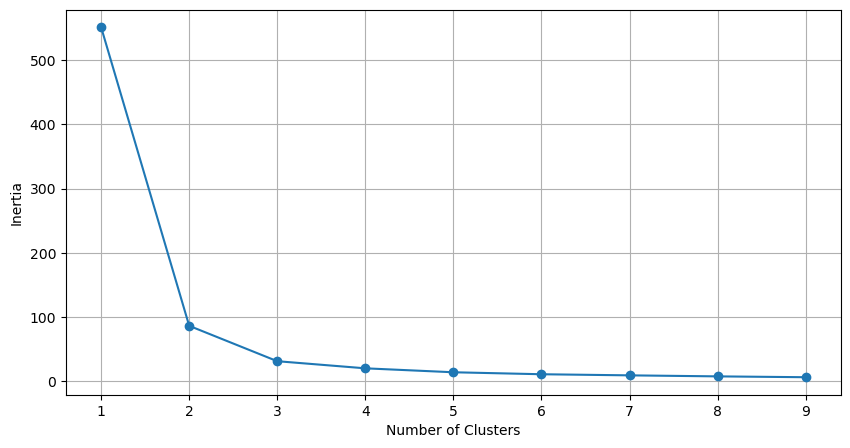

In [22]:
#optimise_k_means(df[['SepalLength_T', 'SepalWidth_T', 'PetalLength', 'PetalWidth']], 10)

optimise_k_means(df[['PetalLength', 'PetalWidth']], 10)

In [23]:
kmeans = KMeans(n_clusters=3)

In [24]:
kmeans.fit(df[['SepalLength_T', 'SepalWidth_T', 'PetalLength', 'PetalWidth']])

C:\Users\liter\Documents\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [25]:
df['kmeans_3'] = kmeans.labels_

In [26]:
df.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth,SepalLength_T,SepalWidth_T,PetalLength_T,PetalWidth_T,kmeans_3
count,150.000000,150.000000,150.000000,150.000000,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02,150.000000
mean,5.843333,3.057333,3.758000,1.199333,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16,1.066667
std,0.828066,0.435866,1.765298,0.762238,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00,0.856610
min,4.300000,2.000000,1.000000,0.100000,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00,0.000000
25%,5.100000,2.800000,1.600000,0.300000,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00,0.000000
50%,5.800000,3.000000,4.350000,1.300000,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01,1.000000
75%,6.400000,3.300000,5.100000,1.800000,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00,2.000000


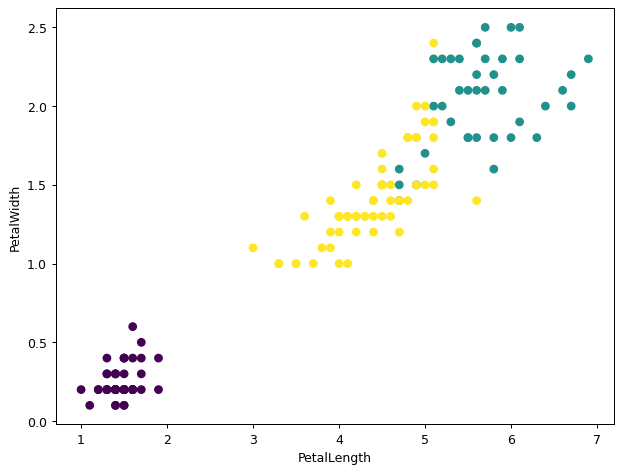

In [27]:
plt.figure(figsize=(8,6), dpi=90)
plt.scatter(x=df['PetalLength'], y=df['PetalWidth'], c=df['kmeans_3'])
plt.xlabel('PetalLength')
plt.ylabel('PetalWidth')
plt.show()

In [28]:
### END OF TASK 2

In [29]:
### START OF TASK 3

In [30]:
# importing dataset for the last task

df = pd.read_csv(r'C:\Users\liter\Downloads\Task3_Data_Process.csv') 

In [31]:
df

,x,y
0,0.287578,1.164440
1,0.788305,-0.887802
2,0.408977,0.174131
3,0.883017,-0.217437
4,0.940467,-0.076454
5,0.045556,0.262857
6,0.528105,-0.450209
7,0.892419,-0.882366
8,0.551435,-0.393132
9,0.456615,0.152015


In [32]:
# train test split for 80/20

X = df[["x"]].values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
# linear regression

lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred_train = lin.predict(X_train)
y_pred_test  = lin.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print("Linear Regression:")
print(f"RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")
print(f"R2   train: {r2_train:.3f} | R2   test: {r2_test:.3f}")
print(f"Intercept: {lin.intercept_:.3f}, Slope: {lin.coef_[0]:.3f}")

Linear Regression:
RMSE train: 0.446 | RMSE test: 0.906
R2   train: 0.346 | R2   test: -1.035
Intercept: 0.261, Slope: -1.093


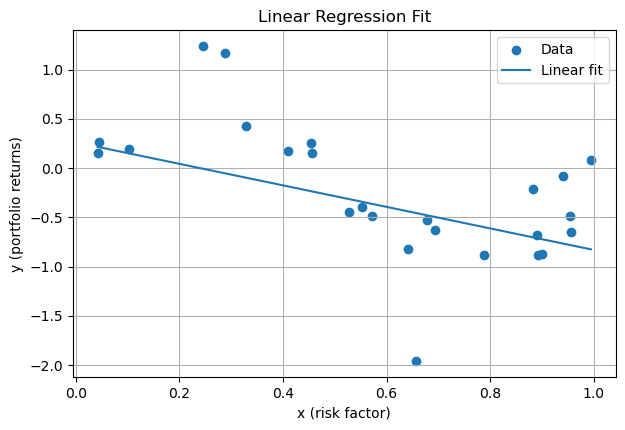

In [42]:
# linear reg. graph

x_grid = np.linspace(df["x"].min(), df["x"].max(), 300).reshape(-1, 1)
y_grid_lin = lin.predict(x_grid)

plt.figure(figsize=(7,4.5), dpi=100)
plt.scatter(df["x"], df["y"], label="Data")
plt.plot(x_grid, y_grid_lin, label="Linear fit")
plt.xlabel("x (risk factor)")
plt.ylabel("y (portfolio returns)")
plt.title("Linear Regression Fit")
plt.grid(True)
plt.legend()
plt.show()

In [45]:
# polynominal regression

poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("lin", LinearRegression())
])

poly3.fit(X_train, y_train)

y2_train = poly3.predict(X_train)
y2_test  = poly3.predict(X_test)

rmse2_train = np.sqrt(mean_squared_error(y_train, y2_train))
rmse2_test  = np.sqrt(mean_squared_error(y_test,  y2_test))
r22_train   = r2_score(y_train, y2_train)
r22_test    = r2_score(y_test,  y2_test)

print("Polynomial Regression (degree=3):")
print(f"RMSE train: {rmse2_train:.3f} | RMSE test: {rmse2_test:.3f}")
print(f"R2   train: {r22_train:.3f} | R2   test: {r22_test:.3f}")

Polynomial Regression (degree=3):
RMSE train: 0.336 | RMSE test: 0.463
R2   train: 0.630 | R2   test: 0.467


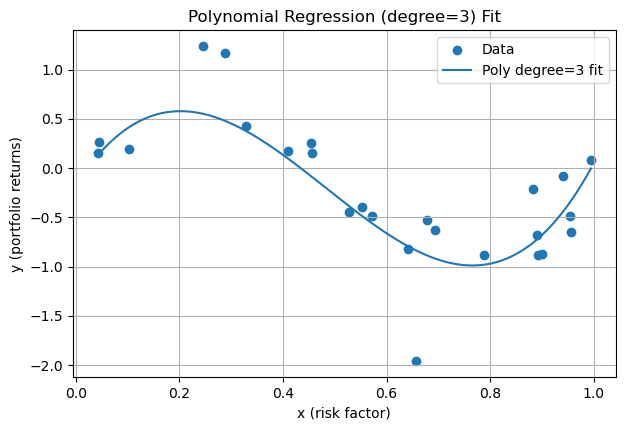

In [44]:
y_grid_poly3 = poly3.predict(x_grid)

plt.figure(figsize=(7,4.5), dpi=100)
plt.scatter(df["x"], df["y"], label="Data")
plt.plot(x_grid, y_grid_poly3, label="Poly degree=3 fit")
plt.xlabel("x (risk factor)")
plt.ylabel("y (portfolio returns)")
plt.title("Polynomial Regression (degree=3) Fit")
plt.grid(True)
plt.legend()
plt.show()
